In [ ]:
# Naive Bayes -> MultinomialNB
# Vectorizer -> CountVectorizer, TfidfVectorizer

In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

In [ ]:
# weight
# It (high repeatition) -> Ignore -> Weight Low
# Malicious (Low repeat) -> Priority -> high Weight

In [14]:
df = pd.read_csv('D:/Broadway/Data Science - 2/movie_review.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
def clean_text(text):
    # Used for cleaning any HTML tags if available in data.
    # <.*(tags)?>
    text = re.sub(r'<.*?>','',text)
    # Remove unwanted symbols, texts
    text = re.sub(r'[^a-zA-Z\s]','',text).lower()
    return text

In [16]:
df['review'] = df['review'].apply(clean_text)

In [18]:
X = df['review']
Y = df['sentiment']

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [55]:
ignore_words = {'not'}
custom_stop_words = list(set(ENGLISH_STOP_WORDS) - ignore_words)

In [56]:
tfidf = TfidfVectorizer(
    # lowercase = True
    stop_words = custom_stop_words,
    ngram_range=(1, 2)
)
X_train_tfidf = tfidf.fit_transform(X_train) # Learn and Implement
X_test_tfidf = tfidf.transform(X_test) # Implement

In [57]:
model = MultinomialNB(alpha=0.1) # default -> alpha = 1

In [58]:
model.fit(X_train_tfidf, Y_train)

,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [59]:
Y_pred = model.predict(X_test_tfidf)

In [60]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [61]:
print(cr)

              precision    recall  f1-score   support

    negative       0.88      0.89      0.89      4961
    positive       0.89      0.88      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [62]:
print(cm)

[[4429  532]
 [ 606 4433]]


<Axes: >

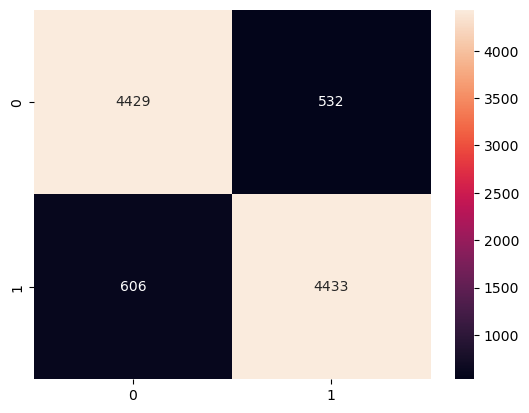

In [63]:
sns.heatmap(cm, annot=True, fmt='.0f')

In [64]:
def predict_text(input_text):
    cleaned_text = clean_text(input_text)
    text_tfidf = tfidf.transform([cleaned_text])
    prediction = model.predict(text_tfidf)[0]
    return prediction

In [66]:
input_text = 'This movie is not bad.'
predict_text(input_text)

np.str_('negative')